In [160]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## Data Acquisition & Merging
**What:** Loading the raw CSV files for features, train data, test data, and store information, then merging them into comprehensive training and testing dataframes.

**Why:** Neural Networks require a unified dataset. By joining these tables on shared keys like `Store` and `Date`, we ensure all relevant predictors (like Markdown events and store sizes) correspond to the correct weekly sales targets.

In [161]:
features_df = pd.read_csv('features.csv')
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
stores_df = pd.read_csv('stores.csv')

In [162]:
merged_train_stores = train_df.merge(stores_df, on='Store', how='inner')
merged_test_stores = test_df.merge(stores_df, on='Store', how='inner')

train_df_final = merged_train_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])
test_df_final = merged_test_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])


## Feature Engineering & Categorical Encoding
**What:** 
- Converting the `Date` string column to datetime objects and extracting the month, day, and day of the week.
- Using `OneHotEncoder` to transform the categorical variables (`IsHoliday`, `Type`, `Dept`) into machine-readable numeric arrays.

**Why:** 
- Neural Networks cannot process raw date strings; extracting datetime components allows the model to capture seasonality (e.g., holiday spikes).
- Categorical encoding is necessary because algorithms require numerical input. One-hot encoding prevents the model from assuming a false ordinal relationship between nominal categories like Store Departments.

In [163]:
# date formatting
train_df_final['Date'] = pd.to_datetime(train_df_final['Date'])
test_df_final['Date'] = pd.to_datetime(test_df_final['Date'])

train_df_final['Month'] = train_df_final['Date'].dt.month
train_df_final['Day'] = train_df_final['Date'].dt.day
train_df_final['dayofweek'] = train_df_final['Date'].dt.dayofweek

test_df_final['Month'] = test_df_final['Date'].dt.month
test_df_final['Day'] = test_df_final['Date'].dt.day
test_df_final['dayofweek'] = test_df_final['Date'].dt.dayofweek



# one hot encoding IsHoliday feature
encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
encoded_train_data = encoder.fit_transform(train_df_final[['IsHoliday', 'Type', 'Dept']])
encoded_test_data = encoder.transform(test_df_final[['IsHoliday', 'Type', 'Dept']])
actual_columns = encoder.get_feature_names_out(['IsHoliday', 'Type', 'Dept'])

train_data = pd.DataFrame(encoded_train_data, index=train_df_final.index, columns=actual_columns)
test_data = pd.DataFrame(encoded_test_data, index=test_df_final.index, columns=actual_columns)

## Data Cleaning
**What:** Concatenating our newly encoded columns with the rest of the dataset, dropping overlapping or redundant columns, and filling `NaN` values in the `MarkDown` columns with `0`.

**Why:** 
- We filled Markdowns with 0 because a `NaN` here does not mean 'missing data'; it represents the absence of a promotional event. 
- Redundant columns (like `Date` after component extraction) are dropped to reduce dimensionality and prevent perfect collinearity.

In [164]:
X_train = pd.concat([train_data, train_df_final.drop(columns=['IsHoliday', 'Type', 'Store', 'Dept'])], axis=1)
X_test = pd.concat([test_data, test_df_final.drop(columns=['IsHoliday', 'Type', 'Store', 'Dept'])], axis=1)

Y_train = X_train[['Weekly_Sales']]
X_train = X_train.drop(columns=['Weekly_Sales', 'Date'])
X_test = X_test.drop(columns=['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
X_train[markdown_cols] = X_train[markdown_cols].fillna(0)
X_test[markdown_cols] = X_test[markdown_cols].fillna(0)


## Feature Scaling
**What:** Identifying continuous numerical columns (those with more than 10 unique values) and applying `StandardScaler` to standardize them to a mean of 0 and standard deviation of 1. We also split the data into train and validation slices.

**Why:** We are scaling these features because raw large integers (like massive `Weekly_Sales` or `MarkDown` values) can overwhelm Neural Network weights, slowing down gradient descent or causing explosive gradients. Standardization ensures all features contribute equally to the learning process.

In [165]:
scaler = StandardScaler()
to_scale_cols = []
n = 10

for col in X_train.columns:
    if X_train[col].nunique() > n:
        to_scale_cols.append(col)

scaled_train_features = scaler.fit_transform(X_train[to_scale_cols])
scaled_features_df = pd.DataFrame(scaled_train_features, columns=to_scale_cols, index=X_train.index)
X_train_df = pd.concat([scaled_features_df, X_train.drop(columns=to_scale_cols)], axis=1)

scaled_test_features = scaler.transform(X_test[to_scale_cols])
scaled_test_features_df = pd.DataFrame(scaled_test_features, columns=to_scale_cols, index=X_test.index)
X_test_df = pd.concat([scaled_test_features_df, X_test.drop(columns=to_scale_cols)], axis=1)


X_train_slice, X_test_slice, Y_train_slice, Y_test_slice = train_test_split(X_train_df, Y_train, test_size=.2)
scaler = StandardScaler()
scaled_Y_train_slice = scaler.fit_transform(Y_train_slice)
scaled_Y_test_slice = scaler.transform(Y_test_slice)

## Model Architecture
**What:** Building a deep Neural Network using the Keras Functional API. The model consists of an input layer, four hidden `Dense` layers using the `relu` activation function (128, 64, 32, and 16 neurons), and a final linear output layer for regression.

**Why:** 
- The `relu` (Rectified Linear Unit) activation function helps the network learn complex, non-linear relationships without suffering from the vanishing gradient problem.
- A `linear` activation in the final node is standard for regression tasks, as it allows the model to predict unbounded continuous numerical values (like Sales).

In [166]:
input = tf.keras.layers.Input(shape=(X_train_df.shape[1], ))
x = tf.keras.layers.Dense(128, activation='relu')(input)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='linear')(x)
print(scaled_Y_train_slice[:5, :])

[[-0.51601342]
 [-0.69440931]
 [-0.42068291]
 [ 0.93582281]
 [ 0.1820746 ]]


In [167]:
model = tf.keras.models.Model(inputs=input, outputs=output)
model.compile(optimizer='adam', metrics=['mse'], loss='mse')


model.fit(X_train_slice, scaled_Y_train_slice, epochs=5, batch_size=32, validation_split=.2)

Epoch 1/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.2767 - mse: 0.2767 - val_loss: 0.1416 - val_mse: 0.1416
Epoch 2/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.1295 - mse: 0.1295 - val_loss: 0.1224 - val_mse: 0.1224
Epoch 3/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.1114 - mse: 0.1114 - val_loss: 0.1004 - val_mse: 0.1004
Epoch 4/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - loss: 0.0965 - mse: 0.0965 - val_loss: 0.0921 - val_mse: 0.0921
Epoch 5/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.0880 - mse: 0.0880 - val_loss: 0.0854 - val_mse: 0.0854


In [170]:
Y_pred = model.predict(X_test_slice)

2635/2635 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


## Evaluation
**What:** Generating predictions on the test slice, calculating the $R^2$ (R-squared) score, and visualizing the actual vs. predicted values using a scatter plot over a diagonal identity line.

**Why:** The $R^2$ score tells us the proportion of the variance in the dependent variable (Sales) that is predictable from the independent variables. The scatter plot allows for a visual sanity check: points closer to the red diagonal line indicate more accurate predictions by the Neural Network.

0.9173758071795094


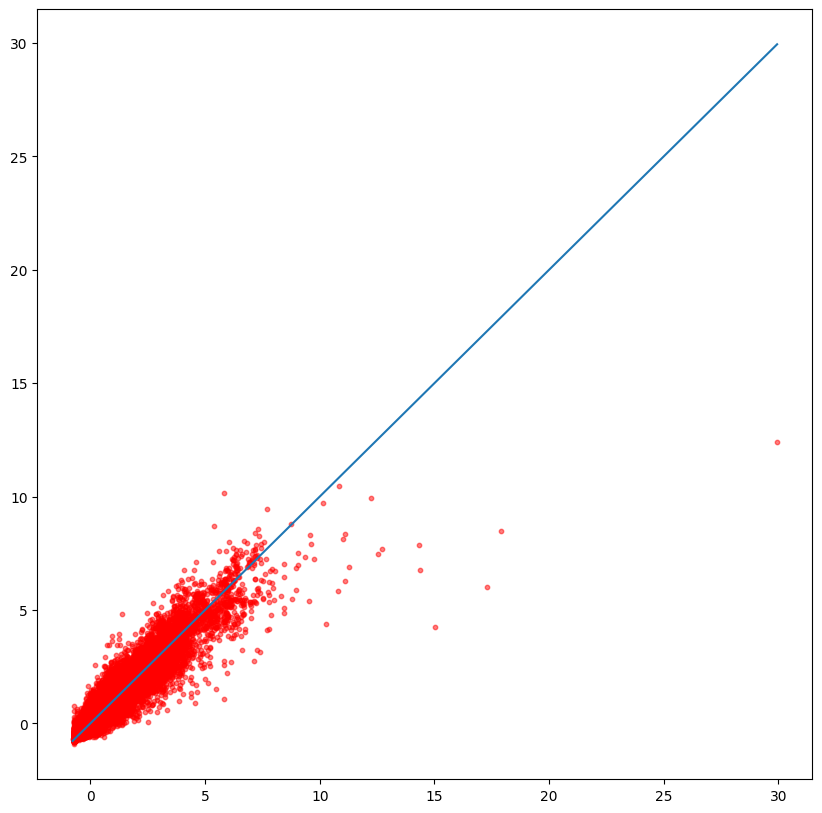

In [172]:
# print(scaled_Y_train_slice[:5, :])
r_2 = r2_score(scaled_Y_test_slice, Y_pred)
print(r_2)
plt.figure(figsize=(10, 10))
plt.plot([scaled_Y_test_slice.min(), scaled_Y_test_slice.max()], [scaled_Y_test_slice.min(), scaled_Y_test_slice.max()])
plt.scatter(scaled_Y_test_slice, Y_pred, alpha=.5, s=10, color='red', label='predictions')
plt.show()